<a href="https://colab.research.google.com/github/Kishoby/Conceptual-Research_Hybrid-Approach/blob/Data-Preprocessing/All_Data_Preprocessing_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np


In [2]:
path="/content/drive/MyDrive/Research v2/Research 18.03.2026/GlobalWeatherRepository (3).csv"
df=pd.read_csv(path)
df.head(5)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15,26.6,79.8,Partly Cloudy,...,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45,19.0,66.2,Partly cloudy,...,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45,23.0,73.4,Sunny,...,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45,6.3,43.3,Light drizzle,...,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45,26.0,78.8,Partly cloudy,...,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [3]:
print(df.isnull().sum())

country                         0
location_name                   0
latitude                        0
longitude                       0
timezone                        0
last_updated_epoch              0
last_updated                    0
temperature_celsius             0
temperature_fahrenheit          0
condition_text                  0
wind_mph                        0
wind_kph                        0
wind_degree                     0
wind_direction                  0
pressure_mb                     0
pressure_in                     0
precip_mm                       0
precip_in                       0
humidity                        0
cloud                           0
feels_like_celsius              0
feels_like_fahrenheit           0
visibility_km                   0
visibility_miles                0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Carbon_Monoxide     0
air_quality_Ozone               0
air_quality_Ni

In [4]:
# Convert to datetime
df['last_updated'] = pd.to_datetime(df['last_updated'], errors='coerce')

# Remove invalid timestamps
df = df.dropna(subset=['last_updated'])

# Sort by time (VERY IMPORTANT for streaming)
df = df.sort_values(by='last_updated')

# Reset index
df = df.reset_index(drop=True)

In [5]:
# Fill numerical missing values
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill categorical missing values
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [6]:
initial_shape = df.shape[0]

df = df.drop_duplicates()

df = df[(df['humidity'] <= 100) &
        (df['temperature_celsius'] > -50) &
        (df['temperature_celsius'] < 60)]

final_shape = df.shape[0]

print(f"Rows before: {initial_shape}")
print(f"Rows after: {final_shape}")
print(f"Rows removed: {initial_shape - final_shape}")

Rows before: 130003
Rows after: 130003
Rows removed: 0


In [7]:
print("Original condition_text values:")
print(df['condition_text'].unique())

print("\nOriginal wind_direction values:")
print(df['wind_direction'].unique())

df['condition_text_before'] = df['condition_text']
df['wind_direction_before'] = df['wind_direction']

from sklearn.preprocessing import LabelEncoder

le_condition = LabelEncoder()
le_wind = LabelEncoder()

df['condition_text'] = le_condition.fit_transform(df['condition_text'])
df['wind_direction'] = le_wind.fit_transform(df['wind_direction'])

condition_table = df[['condition_text_before', 'condition_text']].drop_duplicates().sort_values(by='condition_text')

condition_table

wind_table = df[['wind_direction_before', 'wind_direction']].drop_duplicates().sort_values(by='wind_direction')

wind_table
from IPython.display import display

print("Condition Text Encoding Table:")
display(condition_table)

print("\nWind Direction Encoding Table:")
display(wind_table)

Original condition_text values:
['Clear' 'Partly cloudy' 'Moderate or heavy rain with thunder' 'Mist'
 'Overcast' 'Patchy rain nearby' 'Fog' 'Partly Cloudy' 'Sunny'
 'Moderate or heavy rain shower' 'Light rain' 'Moderate rain'
 'Light drizzle' 'Thundery outbreaks in nearby'
 'Patchy light rain in area with thunder' 'Patchy light rain with thunder'
 'Moderate rain at times' 'Light rain shower' 'Cloudy'
 'Heavy rain at times' 'Patchy light rain' 'Patchy light drizzle'
 'Thundery outbreaks possible' 'Patchy rain possible'
 'Moderate or heavy rain in area with thunder' 'Heavy rain'
 'Torrential rain shower' 'Freezing fog' 'Moderate or heavy snow showers'
 'Light sleet' 'Blizzard' 'Moderate snow' 'Light snow'
 'Light sleet showers' 'Light freezing rain' 'Heavy snow' 'Blowing snow'
 'Patchy heavy snow' 'Light snow showers' 'Moderate or heavy sleet'
 'Patchy light snow' 'Patchy moderate snow' 'Freezing drizzle'
 'Moderate or heavy snow in area with thunder' 'Patchy snow nearby'
 'Patchy snow 

,condition_text_before,condition_text
28883,Blizzard,0
33901,Blowing snow,1
0,Clear,2
354,Cloudy,3
6,Fog,4
44003,Freezing drizzle,5
6986,Freezing fog,6
120537,Heavy freezing drizzle,7
2498,Heavy rain,8
463,Heavy rain at times,9



Wind Direction Encoding Table:


,wind_direction_before,wind_direction
4,E,0
8,ENE,1
5,ESE,2
6,N,3
22,NE,4
24,NNE,5
34,NNW,6
47,NW,7
2,S,8
10,SE,9


In [8]:
df.head(5)

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,...,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,condition_text_before,wind_direction_before
0,United States of America,Washington Park,46.60,-120.49,America/Los_Angeles,1715849100,2024-05-16 01:45:00,16.1,61.0,2,...,1,1,05:26 AM,08:31 PM,01:36 PM,02:52 AM,Waxing Gibbous,55,Clear,SW
1,Honduras,Tegucigalpa,14.10,-87.22,America/Tegucigalpa,1715849100,2024-05-16 02:45:00,23.0,73.4,32,...,2,2,05:22 AM,06:09 PM,12:52 PM,12:55 AM,Waxing Gibbous,55,Partly cloudy,WSW
2,El Salvador,San Salvador,13.71,-89.20,America/El_Salvador,1715849100,2024-05-16 02:45:00,26.0,78.8,23,...,2,2,05:30 AM,06:16 PM,01:00 PM,01:02 AM,Waxing Gibbous,55,Moderate or heavy rain with thunder,S
3,Guatemala,Guatemala City,14.62,-90.53,America/Guatemala,1715849100,2024-05-16 02:45:00,20.0,68.0,19,...,4,10,05:34 AM,06:23 PM,01:05 PM,01:09 AM,Waxing Gibbous,55,Mist,S
4,Belize,Belmopan,17.25,-88.77,America/Belize,1715849100,2024-05-16 02:45:00,26.0,78.9,30,...,1,1,05:23 AM,06:20 PM,12:56 PM,01:04 AM,Waxing Gibbous,55,Overcast,E


In [9]:
from google.colab import files

# Save file temporarily in Colab
df.to_csv("cleaned_weather_data.csv", index=False)

# Download to your computer
files.download("cleaned_weather_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

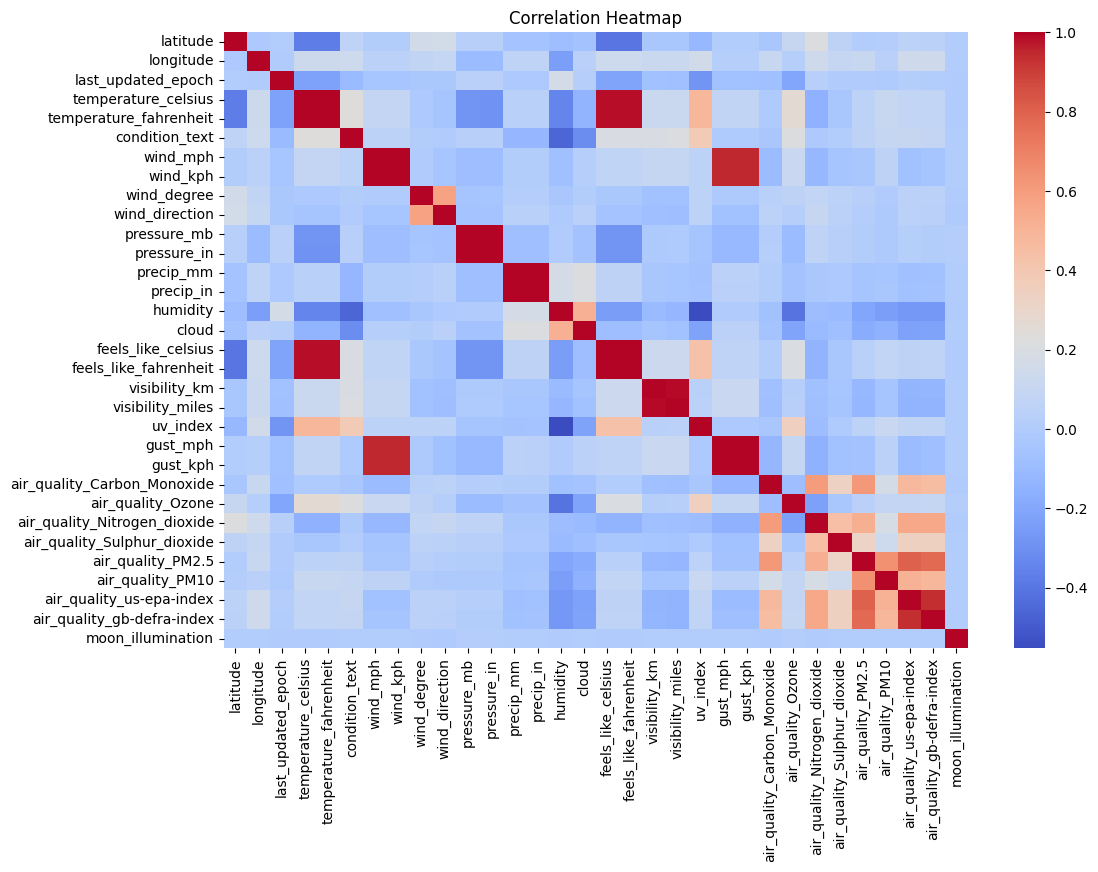

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [11]:
targets = [
    "temperature_celsius",
    "air_quality_PM2.5",
    "humidity"
]

In [12]:
for target in targets:
    corr = df.corr(numeric_only=True)[target].drop(target)

    corr_percent = (corr.abs() * 100).sort_values(ascending=False)

    corr_df = corr_percent.to_frame(name="Correlation Strength (%)")

    print(f"\n=== Correlation Strength with {target} ===")
    display(corr_df)


=== Correlation Strength with temperature_celsius ===


,Correlation Strength (%)
temperature_fahrenheit,99.999727
feels_like_celsius,98.363530
feels_like_fahrenheit,98.363232
uv_index,48.892257
latitude,37.435463
humidity,34.376471
pressure_in,28.587806
pressure_mb,28.518666
air_quality_Ozone,26.550718
condition_text,23.474458



=== Correlation Strength with air_quality_PM2.5 ===


,Correlation Strength (%)
air_quality_us-epa-index,80.563967
air_quality_gb-defra-index,77.722492
air_quality_PM10,64.580468
air_quality_Carbon_Monoxide,61.575360
air_quality_Nitrogen_dioxide,52.312199
air_quality_Sulphur_dioxide,32.586143
humidity,21.026206
cloud,17.881316
visibility_miles,12.635878
visibility_km,11.768691



=== Correlation Strength with humidity ===


,Correlation Strength (%)
uv_index,55.246490
cloud,51.817166
condition_text,45.649334
air_quality_Ozone,41.087863
temperature_celsius,34.376471
temperature_fahrenheit,34.376310
air_quality_us-epa-index,27.243457
air_quality_gb-defra-index,27.004880
feels_like_celsius,24.740011
feels_like_fahrenheit,24.737771


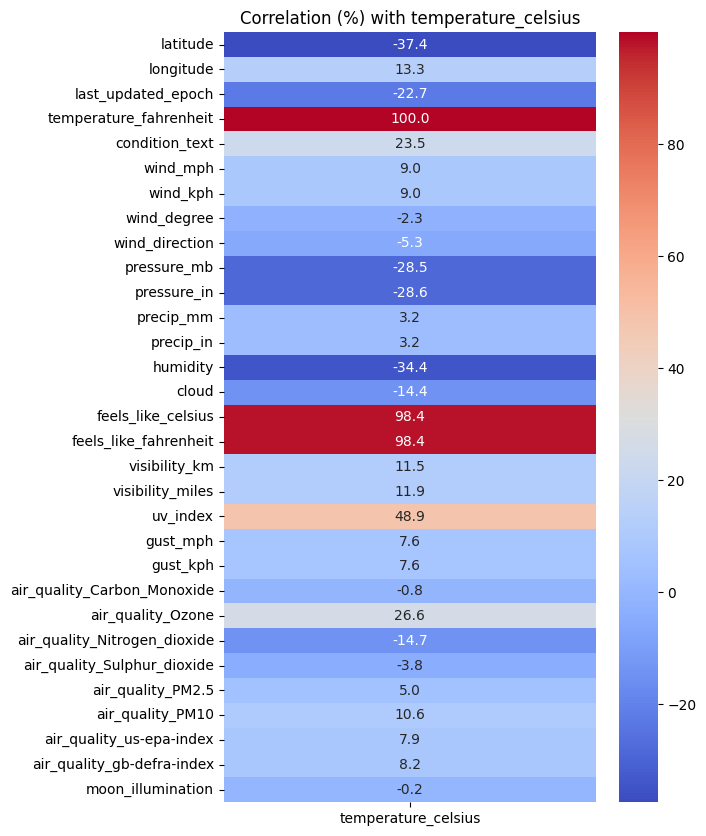

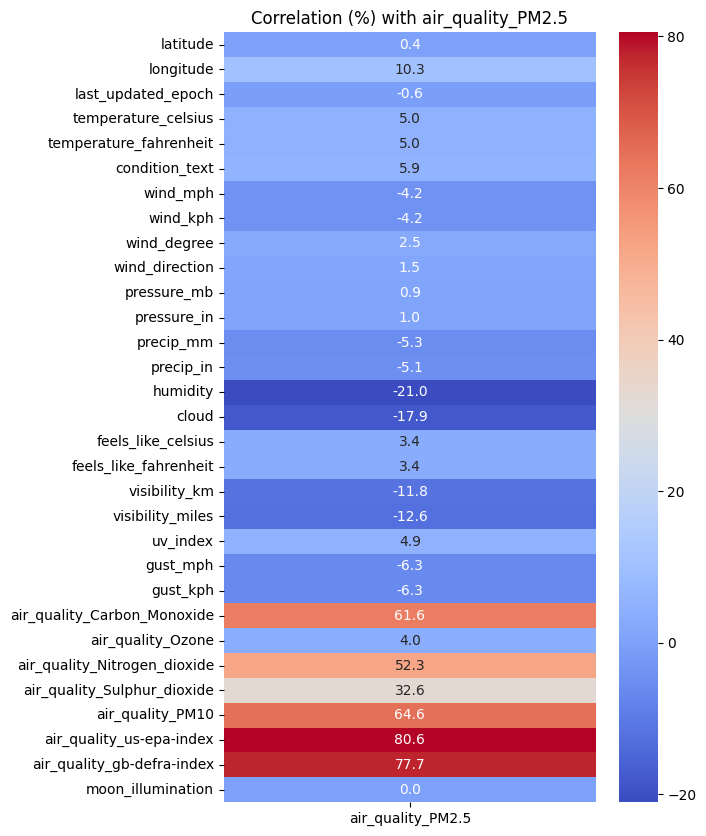

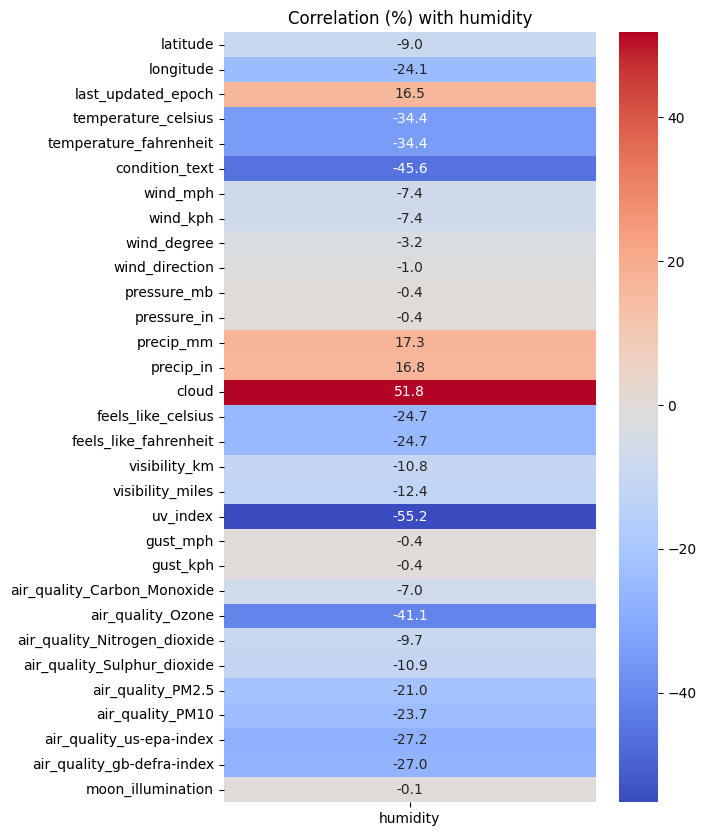

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

targets = [
    "temperature_celsius",
    "air_quality_PM2.5",
    "humidity"
]

for target in targets:
    # Get correlation with target
    corr = df.corr(numeric_only=True)[[target]].drop(target)

    # Convert to percentage
    corr_percent = corr * 100

    # Plot heatmap
    plt.figure(figsize=(6, 10))

    sns.heatmap(
        corr_percent,
        annot=True,
        fmt=".1f",
        cmap="coolwarm",
        cbar=True
    )

    plt.title(f"Correlation (%) with {target}")
    plt.show()